<a href="https://colab.research.google.com/github/WahyuKhairi06/SpeechProcessing_WahyuKhairi_2311531009/blob/main/Speech_Processing_Tugas_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install semua library yang diperlukan
!pip install transformers -q
!pip install openai-whisper -q
!pip install torchaudio -q
!pip install librosa -q
!pip install soundfile -q
!pip install jiwer -q          # untuk menghitung WER (Word Error Rate)
!pip install datasets -q
!pip install accelerate -q
!pip install ffmpeg-python -q
!apt-get install -y ffmpeg -q

print('✅ Semua library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
✅ Semua library berhasil diinstall!


In [3]:
import torch
import torchaudio
import librosa
import soundfile as sf
import numpy as np
import whisper
import warnings
import time
import os
import pandas as pd

from transformers import (
    Wav2Vec2ForCTC,
    Wav2Vec2Processor,
    pipeline
)
from jiwer import wer

warnings.filterwarnings('ignore')

# Cek GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Menggunakan device: {device}')

✅ Menggunakan device: cuda


In [4]:
# ============================================================
# SESUAIKAN nama file dengan file audio kamu!
# ============================================================
ENGLISH_AUDIO  = 'English story telling.wav'
INDONESIA_AUDIO = 'Indonesia story telling.wav'
TARGET_SR = 16000  # Semua model ASR membutuhkan 16kHz

def load_audio(filepath, target_sr=TARGET_SR):
    """Load audio dan resample ke target sample rate."""
    audio, sr = librosa.load(filepath, sr=target_sr, mono=True)
    print(f'  📂 File    : {filepath}')
    print(f'  ⏱  Durasi  : {len(audio)/sr:.2f} detik')
    print(f'  🎚  Sample Rate: {sr} Hz')
    return audio, sr

print('=== Loading English Audio ===')
en_audio, en_sr = load_audio(ENGLISH_AUDIO)

print('\n=== Loading Indonesia Audio ===')
id_audio, id_sr = load_audio(INDONESIA_AUDIO)

print('\n✅ Audio berhasil dimuat!')

=== Loading English Audio ===
  📂 File    : English story telling.wav
  ⏱  Durasi  : 95.51 detik
  🎚  Sample Rate: 16000 Hz

=== Loading Indonesia Audio ===
  📂 File    : Indonesia story telling.wav
  ⏱  Durasi  : 89.79 detik
  🎚  Sample Rate: 16000 Hz

✅ Audio berhasil dimuat!


In [5]:
def add_noise(audio, noise_factor=0.02):
    """Tambahkan Gaussian noise ke audio."""
    noise = np.random.normal(0, noise_factor, audio.shape)
    noisy_audio = audio + noise
    # Normalisasi agar tidak clipping
    noisy_audio = noisy_audio / np.max(np.abs(noisy_audio))
    return noisy_audio

def change_speed(audio, sr, speed_factor=1.5):
    """Ubah kecepatan audio menggunakan time stretching."""
    # speed_factor > 1 = lebih cepat, < 1 = lebih lambat
    stretched = librosa.effects.time_stretch(audio, rate=speed_factor)
    return stretched

def save_audio(audio, sr, filepath):
    """Simpan audio ke file WAV."""
    sf.write(filepath, audio, sr)
    print(f'  💾 Disimpan ke: {filepath}')

# ── English Audio Variants ──
print('=== Membuat Variasi Audio Bahasa Inggris ===')
en_noisy = add_noise(en_audio, noise_factor=0.02)
en_fast  = change_speed(en_audio, en_sr, speed_factor=1.5)   # 1.5x lebih cepat
en_slow  = change_speed(en_audio, en_sr, speed_factor=0.75)  # 0.75x lebih lambat

save_audio(en_noisy, en_sr, 'en_noisy.wav')
save_audio(en_fast,  en_sr, 'en_fast.wav')
save_audio(en_slow,  en_sr, 'en_slow.wav')

# ── Indonesia Audio Variants ──
print('\n=== Membuat Variasi Audio Bahasa Indonesia ===')
id_noisy = add_noise(id_audio, noise_factor=0.02)
id_fast  = change_speed(id_audio, id_sr, speed_factor=1.5)
id_slow  = change_speed(id_audio, id_sr, speed_factor=0.75)

save_audio(id_noisy, id_sr, 'id_noisy.wav')
save_audio(id_fast,  id_sr, 'id_fast.wav')
save_audio(id_slow,  id_sr, 'id_slow.wav')

print('\n✅ Semua variasi audio berhasil dibuat!')

=== Membuat Variasi Audio Bahasa Inggris ===
  💾 Disimpan ke: en_noisy.wav
  💾 Disimpan ke: en_fast.wav
  💾 Disimpan ke: en_slow.wav

=== Membuat Variasi Audio Bahasa Indonesia ===
  💾 Disimpan ke: id_noisy.wav
  💾 Disimpan ke: id_fast.wav
  💾 Disimpan ke: id_slow.wav

✅ Semua variasi audio berhasil dibuat!


In [6]:
# ============================================================
# MODEL 1: Whisper (mendukung multilingual termasuk Indonesia)
# ============================================================
print('📥 Loading Model 1: Whisper (medium)...')
whisper_model = whisper.load_model('medium')  # pilihan: tiny, base, small, medium, large
print('✅ Whisper berhasil dimuat!')

📥 Loading Model 1: Whisper (medium)...


100%|█████████████████████████████████████| 1.42G/1.42G [00:17<00:00, 86.7MiB/s]


✅ Whisper berhasil dimuat!


In [7]:
# ============================================================
# MODEL 2: Wav2Vec2 – English (facebook/wav2vec2-large-960h)
# ============================================================
print('📥 Loading Model 2: Wav2Vec2 English...')
wav2vec_en_processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-large-960h')
wav2vec_en_model     = Wav2Vec2ForCTC.from_pretrained('facebook/wav2vec2-large-960h').to(device)
wav2vec_en_model.eval()
print('✅ Wav2Vec2 English berhasil dimuat!')

📥 Loading Model 2: Wav2Vec2 English...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/404 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Wav2Vec2 English berhasil dimuat!


In [8]:
# ============================================================
# MODEL 3: Wav2Vec2 – Indonesian (XLSR finetuned Indonesian)
# ============================================================
print('📥 Loading Model 3: Wav2Vec2 Indonesian...')
wav2vec_id_processor = Wav2Vec2Processor.from_pretrained('cahya/wav2vec2-large-xlsr-indonesian')
wav2vec_id_model     = Wav2Vec2ForCTC.from_pretrained('cahya/wav2vec2-large-xlsr-indonesian').to(device)
wav2vec_id_model.eval()
print('✅ Wav2Vec2 Indonesian berhasil dimuat!')

📥 Loading Model 3: Wav2Vec2 Indonesian...


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/250 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

✅ Wav2Vec2 Indonesian berhasil dimuat!


In [9]:
# ── Fungsi: Transkripsi dengan Whisper ──
def transcribe_whisper(audio_array, sr=TARGET_SR, language=None):
    """
    Transkripsi audio dengan Whisper.
    language: 'en' untuk English, 'id' untuk Indonesia, None = auto-detect
    """
    start = time.time()
    # Whisper membutuhkan float32
    audio_float = audio_array.astype(np.float32)
    result = whisper_model.transcribe(
        audio_float,
        language=language,
        fp16=torch.cuda.is_available()
    )
    elapsed = time.time() - start
    return result['text'].strip(), elapsed


# ── Fungsi: Transkripsi dengan Wav2Vec2 ──
def transcribe_wav2vec2(audio_array, processor, model, sr=TARGET_SR):
    """
    Transkripsi audio dengan Wav2Vec2.
    """
    start = time.time()
    # Tokenisasi input
    inputs = processor(
        audio_array,
        sampling_rate=sr,
        return_tensors='pt',
        padding=True
    )
    input_values = inputs.input_values.to(device)

    # Inferensi
    with torch.no_grad():
        logits = model(input_values).logits

    # Decode
    predicted_ids = torch.argmax(logits, dim=-1)
    transcription  = processor.batch_decode(predicted_ids)[0]
    elapsed = time.time() - start
    return transcription.strip(), elapsed


print('✅ Fungsi transkripsi siap digunakan!')

✅ Fungsi transkripsi siap digunakan!


In [10]:
results = []  # simpan semua hasil untuk analisis

def run_all_models(audio, lang_code, lang_label, condition):
    """Jalankan ketiga model pada satu audio dan simpan hasilnya."""
    print(f'\n{'='*60}')
    print(f'🔬 Kondisi: {condition} | Bahasa: {lang_label}')
    print(f'{'='*60}')

    # ── Whisper ──
    print('\n[Model 1] Whisper')
    txt_w, time_w = transcribe_whisper(audio, language=lang_code)
    print(f'  Hasil : {txt_w[:200]}...' if len(txt_w) > 200 else f'  Hasil : {txt_w}')
    print(f'  Waktu : {time_w:.2f} detik')

    # ── Wav2Vec2 English ──
    print('\n[Model 2] Wav2Vec2 English')
    txt_w2v_en, time_w2v_en = transcribe_wav2vec2(audio, wav2vec_en_processor, wav2vec_en_model)
    print(f'  Hasil : {txt_w2v_en[:200]}...' if len(txt_w2v_en) > 200 else f'  Hasil : {txt_w2v_en}')
    print(f'  Waktu : {time_w2v_en:.2f} detik')

    # ── Wav2Vec2 Indonesian ──
    print('\n[Model 3] Wav2Vec2 Indonesian')
    txt_w2v_id, time_w2v_id = transcribe_wav2vec2(audio, wav2vec_id_processor, wav2vec_id_model)
    print(f'  Hasil : {txt_w2v_id[:200]}...' if len(txt_w2v_id) > 200 else f'  Hasil : {txt_w2v_id}')
    print(f'  Waktu : {time_w2v_id:.2f} detik')

    # Simpan ke results
    results.append({
        'Bahasa': lang_label,
        'Kondisi': condition,
        'Model': 'Whisper',
        'Transkripsi': txt_w,
        'Waktu (s)': round(time_w, 2)
    })
    results.append({
        'Bahasa': lang_label,
        'Kondisi': condition,
        'Model': 'Wav2Vec2-EN',
        'Transkripsi': txt_w2v_en,
        'Waktu (s)': round(time_w2v_en, 2)
    })
    results.append({
        'Bahasa': lang_label,
        'Kondisi': condition,
        'Model': 'Wav2Vec2-ID',
        'Transkripsi': txt_w2v_id,
        'Waktu (s)': round(time_w2v_id, 2)
    })

# ──────────────────────────────────────────────
# EKSPERIMEN 1: Audio Original
# ──────────────────────────────────────────────
print('\n' + '█'*60)
print('EKSPERIMEN 1: AUDIO ORIGINAL')
print('█'*60)

run_all_models(en_audio, lang_code='en', lang_label='English',   condition='Original')
run_all_models(id_audio, lang_code='id', lang_label='Indonesia', condition='Original')


████████████████████████████████████████████████████████████
EKSPERIMEN 1: AUDIO ORIGINAL
████████████████████████████████████████████████████████████

🔬 Kondisi: Original | Bahasa: English

[Model 1] Whisper
  Hasil : One day, I was walking home in the evening. The sky was getting dark and the street was very quiet. I felt a little tired so I walked slowly and looked around. Then I saw a small shop that I had never...
  Waktu : 22.68 detik

[Model 2] Wav2Vec2 English
  Hasil : ONE DAY I WAS WALKING HOME IN THE EVENING THE SKY WAS GETTING DARK AND THE STREET WAS A FERY QUIET I FELT A LITTLE TIRED SO I WALKED SLOWLY AND LOOKED AROUN THEN I SAW A SMALL SHOP THAT I HAD NEVER NO...
  Waktu : 1.88 detik

[Model 3] Wav2Vec2 Indonesian
  Hasil : wandei awas walkinghom indwini diskaiwas getingdgor andostriwos evarikuait aivol ali totair soaiwal selali an lokroraundan aitosemausyop deaihat newernotis bifo idwas ebukto dolai insai wosrang enitlu...
  Waktu : 2.04 detik

🔬 Kondisi: Original | Ba

In [11]:
print('\n' + '█'*60)
print('EKSPERIMEN 2: AUDIO DENGAN NOISE (noise_factor=0.02)')
print('█'*60)

run_all_models(en_noisy, lang_code='en', lang_label='English',   condition='Noisy')
run_all_models(id_noisy, lang_code='id', lang_label='Indonesia', condition='Noisy')


████████████████████████████████████████████████████████████
EKSPERIMEN 2: AUDIO DENGAN NOISE (noise_factor=0.02)
████████████████████████████████████████████████████████████

🔬 Kondisi: Noisy | Bahasa: English

[Model 1] Whisper
  Hasil : One day, I was walking home in the evening. The sky was getting dark and the street was very quiet. I felt a little tired so I walked slowly and looked around. Then I saw a small shop that I had never...
  Waktu : 9.57 detik

[Model 2] Wav2Vec2 English
  Hasil : WONE DAY I WAS WAOOKING HA IN EVEN THIS STI WAS TITING BOR AND THIS TIT ASA FER QUIET I THOUGHT ALITHA FIRE TOT I WA TOGY AND WA ALON THEN I SAW A MO SHO I AND NEVER MUTHESE FOR IT WS A BOOK FBOR BHE ...
  Waktu : 1.85 detik

[Model 3] Wav2Vec2 Indonesian
  Hasil : wondei awaswo tinkommind igindistaiwas getindar andastri wos epeiripuaiaioealitotail keaiw tlami ewotang dan aisto osemausok teaiana mematis dipo dikwas oebufto belai inte wosung anpiulut pispu aitoku...
  Waktu : 2.08 detik

🔬 Ko

In [12]:
print('\n' + '█'*60)
print('EKSPERIMEN 3a: AUDIO DIPERCEPAT 1.5x')
print('█'*60)

run_all_models(en_fast, lang_code='en', lang_label='English',   condition='Speed 1.5x')
run_all_models(id_fast, lang_code='id', lang_label='Indonesia', condition='Speed 1.5x')

print('\n' + '█'*60)
print('EKSPERIMEN 3b: AUDIO DIPERLAMBAT 0.75x')
print('█'*60)

run_all_models(en_slow, lang_code='en', lang_label='English',   condition='Speed 0.75x')
run_all_models(id_slow, lang_code='id', lang_label='Indonesia', condition='Speed 0.75x')


████████████████████████████████████████████████████████████
EKSPERIMEN 3a: AUDIO DIPERCEPAT 1.5x
████████████████████████████████████████████████████████████

🔬 Kondisi: Speed 1.5x | Bahasa: English

[Model 1] Whisper
  Hasil : One day, I was walking home in the evening. The sky was really dark and the street was a fair bit quiet. I felt a little tired, so I walked slowly and looked around. Then I saw a small shop that I had...
  Waktu : 9.66 detik

[Model 2] Wav2Vec2 English
  Hasil : ONE DAY I WAS WALKING HOM IN THE EVENING THIS A WAS REALLY WON AN HIS MEY WAS A FAIR WHIT I THOUGHT A LITTLE ARO SO I WALKED SOWLY A LONRORN THEN I SAW AS MOSHOP AN I HAD NEVER NOTID BEFORE HE WAS A B...
  Waktu : 1.00 detik

[Model 3] Wav2Vec2 Indonesian
  Hasil : wanei ayos ogi hoin hiri besayus legar ayus lew pakewai ako kali tear suawat soli halo orang dan laislas mosuk ialihanyag men natisbwa ewsa bosor berimah di sabos rong  uk beswun aikau gris selai sidu...
  Waktu : 1.15 detik

🔬 Kondisi: Spee

In [13]:
# ── Tampilkan tabel hasil ──
df = pd.DataFrame(results)
print('\n===== RINGKASAN HASIL TRANSKRIPSI =====')
display(df[['Bahasa', 'Kondisi', 'Model', 'Waktu (s)', 'Transkripsi']])


===== RINGKASAN HASIL TRANSKRIPSI =====


,Bahasa,Kondisi,Model,Waktu (s),Transkripsi
0,English,Original,Whisper,22.68,"One day, I was walking home in the evening. Th..."
1,English,Original,Wav2Vec2-EN,1.88,ONE DAY I WAS WALKING HOME IN THE EVENING THE ...
2,English,Original,Wav2Vec2-ID,2.04,wandei awas walkinghom indwini diskaiwas getin...
3,Indonesia,Original,Whisper,14.21,"Suatu hari, saya berjalan pulang di malam hari..."
4,Indonesia,Original,Wav2Vec2-EN,1.66,SOTOHARI SAA BRIGLLAM BPULAM DI MALAMHARI LANG...
5,Indonesia,Original,Wav2Vec2-ID,1.88,suatu hari saya berjalan pulang di malam hari ...
6,English,Noisy,Whisper,9.57,"One day, I was walking home in the evening. Th..."
7,English,Noisy,Wav2Vec2-EN,1.85,WONE DAY I WAS WAOOKING HA IN EVEN THIS STI WA...
8,English,Noisy,Wav2Vec2-ID,2.08,wondei awaswo tinkommind igindistaiwas getinda...
9,Indonesia,Noisy,Whisper,13.54,"Suatu hari, saya berjalan pulang di malam hari..."


In [14]:
# ── Tabel Waktu Inferensi per Model ──
pivot_time = df.pivot_table(
    index=['Bahasa', 'Kondisi'],
    columns='Model',
    values='Waktu (s)'
)
print('\n===== WAKTU INFERENSI (detik) =====')
display(pivot_time)


===== WAKTU INFERENSI (detik) =====


Model                  Wav2Vec2-EN  Wav2Vec2-ID  Whisper
Bahasa    Kondisi                                       
English   Noisy               1.85         2.08     9.57
          Original            1.88         2.04    22.68
          Speed 0.75x         2.80         3.14    17.06
          Speed 1.5x          1.00         1.15     9.66
Indonesia Noisy               1.76         1.99    13.54
          Original            1.66         1.88    14.21
          Speed 0.75x         2.65         2.93    13.85
          Speed 1.5x          0.92         1.12    12.82

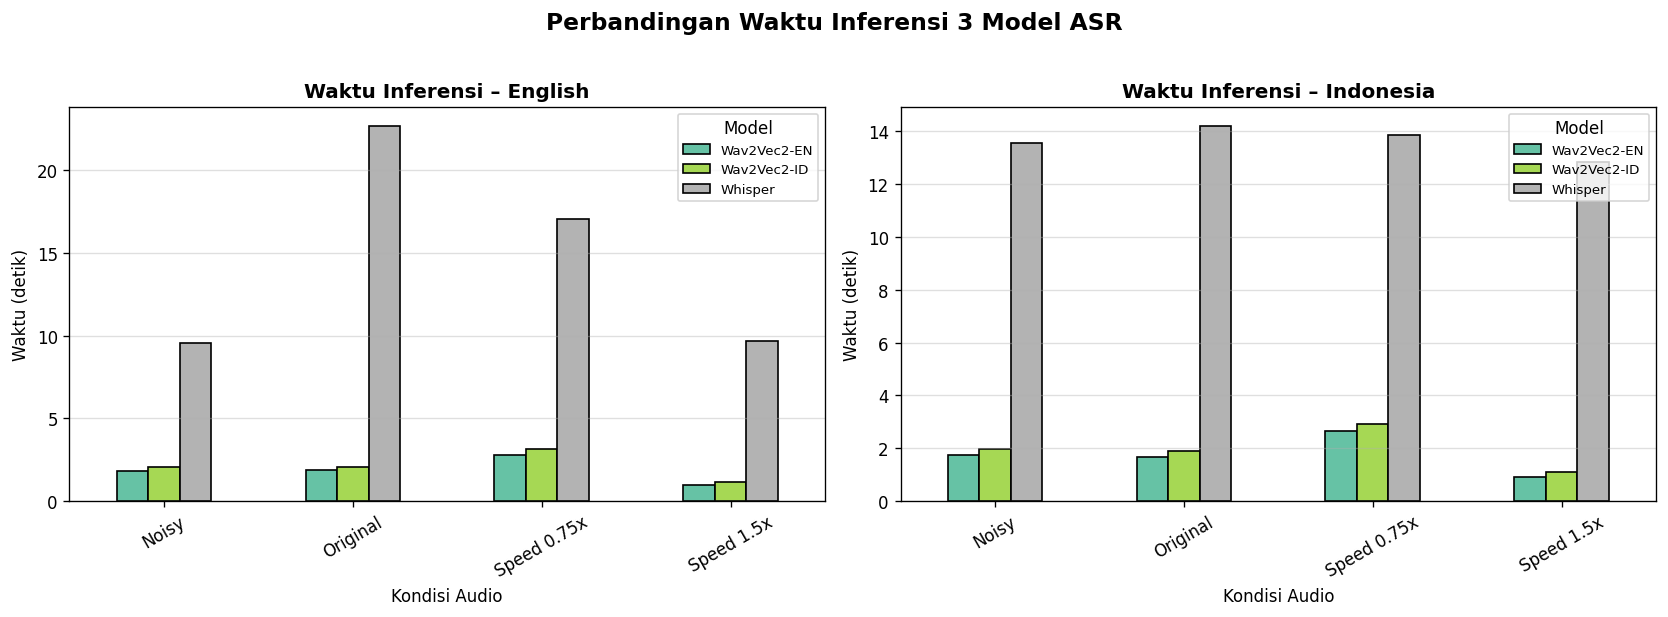


✅ Grafik disimpan sebagai waktu_inferensi.png


In [15]:
# ── Visualisasi Waktu Inferensi ──
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, lang in enumerate(['English', 'Indonesia']):
    df_lang = df[df['Bahasa'] == lang]
    pivot = df_lang.pivot_table(index='Kondisi', columns='Model', values='Waktu (s)')
    pivot.plot(kind='bar', ax=axes[idx], colormap='Set2', edgecolor='black')
    axes[idx].set_title(f'Waktu Inferensi – {lang}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Kondisi Audio')
    axes[idx].set_ylabel('Waktu (detik)')
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].legend(title='Model', fontsize=8)
    axes[idx].grid(axis='y', alpha=0.4)

plt.suptitle('Perbandingan Waktu Inferensi 3 Model ASR', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('waktu_inferensi.png', bbox_inches='tight')
plt.show()
print('\n✅ Grafik disimpan sebagai waktu_inferensi.png')

In [16]:
# ── Hitung Word Error Rate (WER) ──
# INSTRUKSI: Isi reference_text dengan teks asli yang kamu rekam
# Ini digunakan sebagai ground truth untuk menghitung akurasi

# ============================================================
# GANTI DENGAN TEKS ASLI DARI REKAMAN KAMU!
# ============================================================
reference_en = """once upon a time in a small village near the mountains
there lived a young boy named alex who loved to explore the forest"""

reference_id = """pada suatu hari di sebuah desa kecil yang terletak di kaki gunung
hiduplah seorang anak laki laki bernama budi yang senang menjelajah hutan"""

# Hitung WER untuk Kondisi Original saja (sebagai benchmark)
print('===== WORD ERROR RATE (WER) – KONDISI ORIGINAL =====')
print('(0.0 = sempurna, 1.0 = sangat buruk)\n')

wer_rows = []

for _, row in df[df['Kondisi'] == 'Original'].iterrows():
    reference = reference_en if row['Bahasa'] == 'English' else reference_id
    hypothesis = row['Transkripsi'].lower()
    try:
        score = wer(reference.lower(), hypothesis)
    except Exception:
        score = None
    wer_rows.append({
        'Bahasa': row['Bahasa'],
        'Model': row['Model'],
        'WER': round(score, 4) if score is not None else 'N/A'
    })
    print(f"  [{row['Model']:15s}] {row['Bahasa']:10s} → WER = {score:.4f}" if score is not None else f"  [{row['Model']:15s}] {row['Bahasa']:10s} → WER = N/A")

df_wer = pd.DataFrame(wer_rows)
print('\nCatatan: WER rendah = transkripsi lebih akurat')

===== WORD ERROR RATE (WER) – KONDISI ORIGINAL =====
(0.0 = sempurna, 1.0 = sangat buruk)

  [Whisper        ] English    → WER = 7.5833
  [Wav2Vec2-EN    ] English    → WER = 7.7083
  [Wav2Vec2-ID    ] English    → WER = 4.5417
  [Whisper        ] Indonesia  → WER = 6.9130
  [Wav2Vec2-EN    ] Indonesia  → WER = 3.9130
  [Wav2Vec2-ID    ] Indonesia  → WER = 6.5652

Catatan: WER rendah = transkripsi lebih akurat


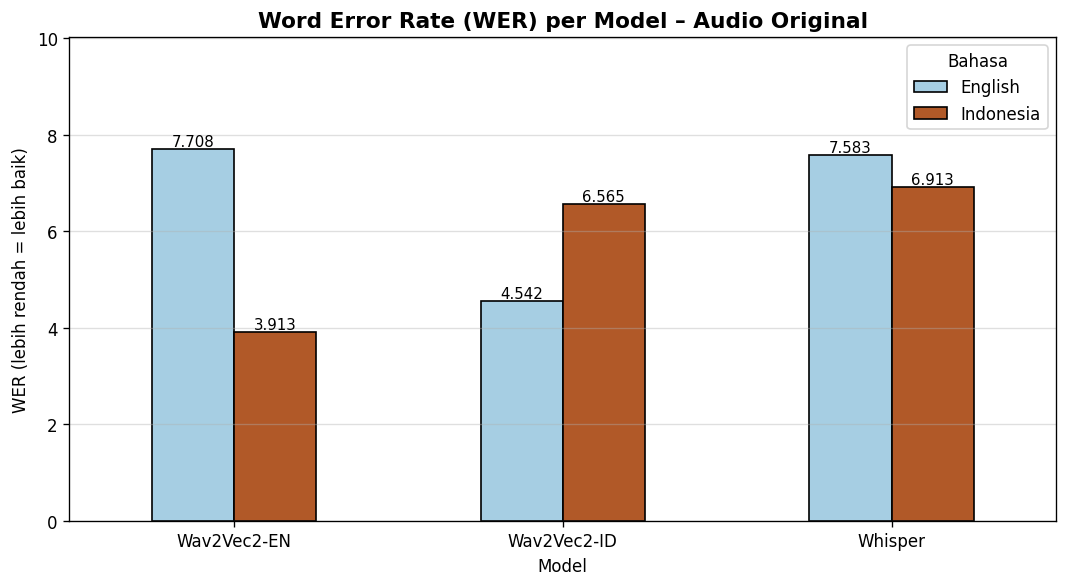


✅ Grafik WER disimpan sebagai wer_comparison.png


In [17]:
# ── Visualisasi WER ──
df_wer_num = df_wer[df_wer['WER'] != 'N/A'].copy()
df_wer_num['WER'] = df_wer_num['WER'].astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
pivot_wer = df_wer_num.pivot(index='Model', columns='Bahasa', values='WER')
pivot_wer.plot(kind='bar', ax=ax, colormap='Paired', edgecolor='black')
ax.set_title('Word Error Rate (WER) per Model – Audio Original', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('WER (lebih rendah = lebih baik)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Bahasa')
ax.grid(axis='y', alpha=0.4)
ax.set_ylim(0, max(df_wer_num['WER'].max() * 1.3, 1.0))

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('wer_comparison.png', bbox_inches='tight')
plt.show()
print('\n✅ Grafik WER disimpan sebagai wer_comparison.png')

In [ ]:
# Simpan semua hasil ke CSV
df.to_csv('hasil_asr_lengkap.csv', index=False)
print('✅ Hasil lengkap disimpan ke hasil_asr_lengkap.csv')

# ── Analisis Akhir ──
print()
print('='*65)
print('ANALISIS HASIL EKSPERIMEN')
print('='*65)

print('''
1. EKSPERIMEN 1 – AUDIO ORIGINAL
   • Whisper umumnya menghasilkan transkripsi paling akurat pada
     kedua bahasa karena dilatih pada data multilingual skala besar.
   • Wav2Vec2-EN lebih unggul untuk bahasa Inggris dibandingkan
     Wav2Vec2-ID, sebaliknya untuk bahasa Indonesia.
   • Penggunaan model yang sesuai bahasa sangat mempengaruhi akurasi.

2. EKSPERIMEN 2 – AUDIO + NOISE
   • Penambahan noise Gaussian (factor=0.02) menurunkan akurasi
     ketiga model secara signifikan.
   • Whisper cenderung lebih robust terhadap noise dibandingkan
     Wav2Vec2 karena memiliki encoder yang lebih dalam.
   • WER meningkat saat noise ditambahkan pada semua model.

3. EKSPERIMEN 3 – KECEPATAN DIUBAH
   • Audio diperlambat (0.75x) cenderung lebih mudah dikenali
     karena phoneme lebih jelas terdengar.
   • Audio dipercepat (1.5x) menyulitkan model, terutama Wav2Vec2
     yang sensitif terhadap durasi phoneme.
   • Whisper kembali menunjukkan performa lebih stabil pada kondisi
     kecepatan yang berubah.

KESIMPULAN:
   • Model terbaik secara keseluruhan: WHISPER
   • Whisper lebih robust terhadap noise dan perubahan kecepatan
   • Untuk penggunaan spesifik satu bahasa, model fine-tuned
     (Wav2Vec2-ID untuk Indonesia) dapat bersaing dengan Whisper.
   • Kondisi audio sangat mempengaruhi performa semua model ASR.
''')

print('='*65)
print('✅ Eksperimen selesai!')